# **1. Experimental Introduction**

## **1.1 Experiment Content**

This experiment uses a dataset of student study hours and grades. By performing linear regression, it builds and optimizes a model that can simply predict approximate grades based on students' study hours.

## **1.2 Experiment Highlights**

Understand the basic concepts of regression analysis.
Master the basic steps of performing regression analysis using Python and the scikit-learn library.
Experience the application of artificial intelligence techniques in the humanities.

## **1.3 Experiment Environment**

- Python 3.10.16
- numpy 1.26.4
- pandas 2.2.3
- matplotlib 3.10.0
- scikit-learn 1.6.1

# **2. Experimental Steps**



## **2.1 Experiment Principle**

Exam score prediction is a typical regression problem, which involves predicting a target variable (e.g., exam score) based on known features (e.g., study hours). By using a regression model, we can establish the relationship between features and the target variable, thereby predicting the target variable for new data.

Below are the dependencies required for the experiment:

- numpy
- pandas
- matplotlib
- scikit-learn

<font color="red">Complete the code block below to **import** required libraries</font>

In [1]:
import pandas as pd  # for data analysis
import matplotlib.pyplot as plt  # for data visualization
from sklearn.linear_model import LinearRegression  # linear regression model
from sklearn.model_selection import train_test_split, GridSearchCV  # dataset splitting and parameter tunning
from sklearn.metrics import mean_squared_error, r2_score  # model evaluation metrics

## **2.2 Data Preparation**

The dataset is located in the `grade.csv` file within the experiment data. The first column represents study hours (unit: hours), and the second column represents exam scores. Each row corresponds to one student's data. Below is a sample of the data format:

| time | score |
| :---: | :---: |
|5.72|53.97|
|6.12|60.02|
|7.17|71.67|
|7.11|71.17|
|6.03|58.17|

<font color="red">Use the `read_csv` function from the pandas data analysis library to read the **CSV** data file.</font>

In [2]:
# Read the data as DataFrame
import os
possible_paths = ['grade.csv', './grade.csv', 'data/grade.csv', './data/grade.csv']
for p in possible_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print('Loaded', p)
        break
else:
    raise FileNotFoundError('grade.csv not found in expected locations. Put the file next to the notebook or in a data/ subfolder.')
# show the first rows
df.head()

Loaded grade.csv


,time,score
0,5.72,53.97
1,6.12,60.02
2,7.17,71.67
3,7.11,71.17
4,6.03,58.17


<font color="red">Extract the `time` column as a **DataFrame** object for input X, and extract the `score` column as a **Series** object for output y.</font>

> Newer versions of scikit-learn require that a two-dimensional array be passed to the model when using `fit()`. When X has only one column, you must use the `[['column_name']]` syntax, which returns a DataFrame object that can be used for model training.

In [3]:
# Extract the feature 'time' as the independent variable X (note: X is a 2D array)
X = df[['time']]
# Extract the target variable 'score' as the dependent variable y
y = df['score']
# show shapes for sanity check
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (150, 1) y shape: (150,)


<font color="red">Split the training data into training set and test set in an **8:2 ratio**, with the random seed set to **100**.</font>

In [4]:
# Splitting X and y as training/testing sets
# test_size=0.2 means the test set is 20% and the training set is 80%
# random_state=100 sets the random seed to ensure the split is reproducible across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
print('Training samples:', X_train.shape[0], 'Test samples:', X_test.shape[0])

Training samples: 120 Test samples: 30


## **2.3 Model Training**


<font color="red">Pass the **training** set into the model for training.</font>
<font color="red">Construct the linear regression model and set its **intercept to zero**.</font>

In [5]:
# Create a linear regression model and train it using the training set data (X_train and y_train).
# Instruction: set the intercept to zero for this training (fit_intercept=False)
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


In [6]:
# Output model parameters
coef = model.coef_
intercept = model.intercept_
print('Coefficient (slope):', coef if getattr(coef, 'shape', (1,))[0]>1 else coef[0])
print('Intercept:', intercept)

Coefficient (slope): 10.067363261132979
Intercept: 0.0


## **2.4 Model Testing and Evaluation**

After training is completed, use the test set to calculate evaluation metrics, i.e., MSE, $R^2$

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

<font color="red">Pass the **test** set into the model for prediction.</font>

<font color="red">Calculate the **MSE, R2** by comparing the true values and predicted values in test set.</font>

In [7]:
# Make predictions on the test set
# Use the trained model to predict on X_test and obtain predicted values y_test_pred
y_test_pred = model.predict(X_test)
# Compute evaluation metrics, i.e., MSE and R².
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
# keep values for later comparison
mse_orig = mse
r2_orig = r2

In [8]:
# Output evaluation metric values
print(f'Original model MSE: {mse_orig:.4f}')
print(f'Original model R^2: {r2_orig:.4f}')

Original model MSE: 19.3042
Original model R^2: 0.8462


## **2.5 Visualization**


<font color="red">Plot the data points and fitted results in a single figure, where the **blue** points are the training set data points, the **green** points are the test set data points, and the fitted line segment is in **red**.</font>

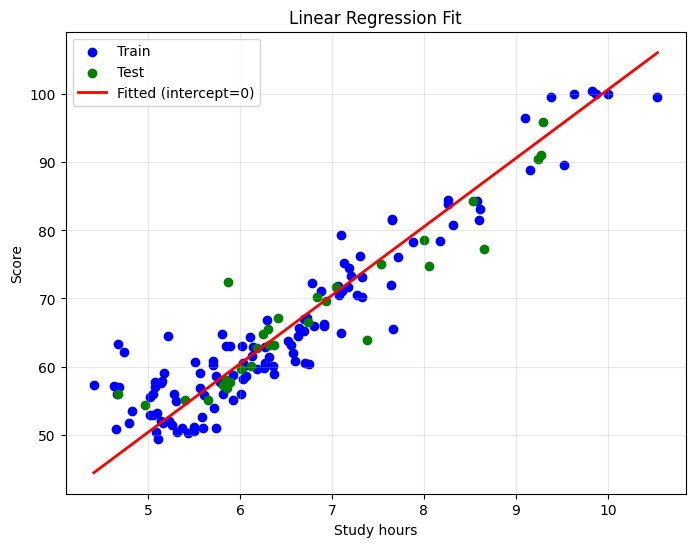

In [9]:
# Draw data points and fitted line
plt.figure(figsize=(8,6))
plt.scatter(X_train['time'], y_train, color='blue', label='Train')
plt.scatter(X_test['time'], y_test, color='green', label='Test')
# line from the trained model (original, red)
X_line = pd.concat([X_train, X_test]).sort_values(by='time')
y_line = model.predict(X_line)
plt.plot(X_line['time'], y_line, color='red', linewidth=2, label='Fitted (intercept=0)')
plt.xlabel('Study hours')
plt.ylabel('Score')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **2.6 Model Optimization**

Below, by setting different parameters of the model, we search for the optimal model.

- <font color="red">fit_intercept: whether to set the bias (intercept in a 2D coordinate system); when False, the bias is set to 0.</font>

In [10]:
# Define a hyperparameter grid for grid search
param_grid = {'fit_intercept': [True, False]}
param_grid

{'fit_intercept': [True, False]}

<font color="red">Perform model training and evaluation with different parameters by constructing a **GridSearch** object. The evaluation score uses the **negative of the mean squared error**; the larger the value, the better the model.</font>

In [11]:
# Create a GridSearchCV instance for hyperparameter tuning
grid = GridSearchCV(LinearRegression(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid

,estimator,LinearRegression()
,param_grid,"{'fit_intercept': [True, False]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


In [12]:
# Run the grid search on the training set to find the best hyperparameter combination
grid.fit(X_train, y_train)
print('Grid search completed.')

Grid search completed.


<font color="red">Output the **best model parameter and the metric values**</font>

In [13]:
# Get the best model and its parameters
best_estimator = grid.best_estimator_
best_params = grid.best_params_
print('Best params:', best_params)
best_estimator

Best params: {'fit_intercept': True}


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Evaluate the model's performance on the test set
# Use the best model to predict on X_test to obtain the predicted values
y_test_best = best_estimator.predict(X_test)
# Compute the MSE between the predicted values and the true values
mse_best = mean_squared_error(y_test, y_test_best)
r2_best = r2_score(y_test, y_test_best)

In [15]:
# Output the best parameters and the mean squared error of the model.
print('Best parameters (GridSearch):', best_params)
print(f'Best model MSE on test set: {mse_best:.4f}')
print(f'Best model R^2 on test set: {r2_best:.4f}')

Best parameters (GridSearch): {'fit_intercept': True}
Best model MSE on test set: 15.2705
Best model R^2 on test set: 0.8784


<font color="red">Compare the optimal result with the previous results; the **optimal** one is shown in **yellow**.</font>

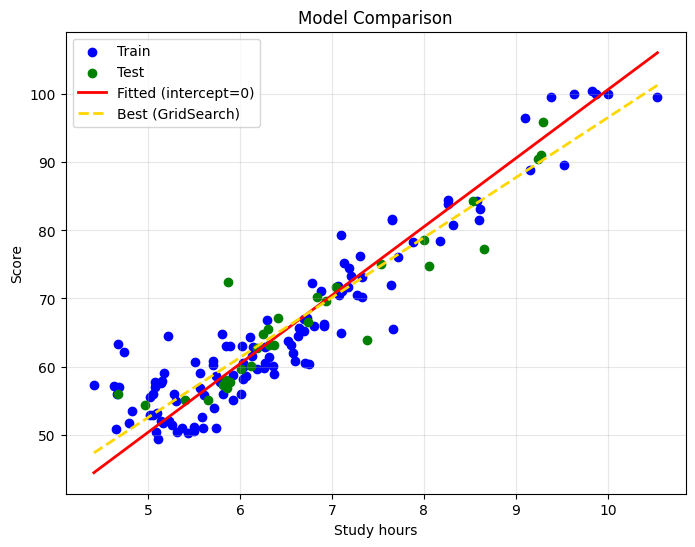

In [16]:
# Draw data points and fitted line (compare original and grid-search best)
plt.figure(figsize=(8,6))
plt.scatter(X_train['time'], y_train, color='blue', label='Train')
plt.scatter(X_test['time'], y_test, color='green', label='Test')
X_line = pd.concat([X_train, X_test]).sort_values(by='time')
# original model line (red)
y_line_orig = model.predict(X_line)
plt.plot(X_line['time'], y_line_orig, color='red', linewidth=2, label='Fitted (intercept=0)')
# best model line from grid search (yellow)
y_line_best = best_estimator.predict(X_line)
plt.plot(X_line['time'], y_line_best, color='gold', linewidth=2, linestyle='--', label='Best (GridSearch)')
plt.xlabel('Study hours')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()